# Train the updated emulator model from Nov 27, 2024, in which there is a scale cut at 8 arcmin. Here we also use the updated fastnc, correcting for a bug on the Nov 2 model, and update the baryon parameter, correcting for a problem in the Nov 25 model.

In [1]:
#Here are the fastnc configs

#[fastnc]
#file = ${COSMOSIS_3PCF_INTEGRATOR}/python/fastnc_interface.py
#Lmax = 50
#Mmax = 100
#nfft = 150
#projection=cent
#dlnt = 0.253758
#use-pixwin = T
#nside = 1024
#mu = 0 1 2 3
#n-phi-bin = 60
#phi-min = 0.01570796
#phi-max = 3.12588469
#n-theta-bin = 9
#theta-min = 8.15147113
#theta-max = 62.0703205
#use_cache = T
#NLA = T

In [2]:
import numpy as np
import random 
import multiprocessing
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
import copy

from cosmopower import cosmopower_NN
from scipy import interpolate
from scipy import signal

In [3]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu' 
print('using', device, 'device \n')

# setting the seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [4]:
path_to_train = '../../'
training_info_1 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-Nov27-list1.txt")
training_info_2 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-Nov27-list2.txt")

In [5]:
training_info_1and2 = np.concatenate((training_info_1, training_info_2), axis=0)

print(training_info_1and2[21])

[ 3.93125000e-01  8.08750000e-01  3.12500000e-02  9.51250000e-01
 -1.00000000e+00  7.35937500e-01  7.73000000e-02  3.00000000e+00
  3.04600000e+00  0.00000000e+00  6.97186000e-02  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  6.20000000e-01
  4.90000000e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.00000000e+00  0.00000000e+00  2.46569504e+08  3.18645725e+08
  1.56606054e+08  3.91644385e+07  3.76665934e+09  4.17283366e+09
  1.72453082e+09  3.52981583e+08  4.76169420e+10  4.11500883e+10
  1.34614659e+10  2.17945678e+09  1.83376670e+11  1.30870640e+11
  3.64622053e+10  5.15887243e+09  4.40667136e+11  2.69263295e+11
  6.66169177e+10  8.69523439e+09  8.24425136e+11  4.42536878e+11
  1.00228843e+11  1.24949084e+10  1.91473530e+12  8.40655322e+11
  1.70596064e+11  2.06077701e+10  4.01499689e+12  1.45463741e+12
  2.78515966e+11  3.43553357e+10  7.55519877e+12  2.40785066e+12
  4.76686146e+11  6.29893

In [6]:
param_indices = [0,5,1,2,3]
training_info = np.ndarray(shape=(len(training_info_1and2),149))
training_info[:,:5] = training_info_1and2[:,param_indices]
training_info[:,5::4] = training_info_1and2[:,26:170:4]
training_info[:,6::4] = training_info_1and2[:,27:170:4]
training_info[:,7::4] = training_info_1and2[:,28:170:4]
training_info[:,8::4] = training_info_1and2[:,29:170:4]

In [7]:
print(np.shape(training_info))
lx = []
for i in range(len(training_info)):
    ss = 0
    for j in range(len(training_info[0])):
        if (np.isnan(training_info[i][j]) or training_info[i][j]<0) and ss == 0:
            ss = 1
    if ss == 0:
        lx.append(i)

lx = np.array(lx)
#print(len(lx))
training_info = training_info[lx,:]
print(np.shape(training_info))

(1500, 149)
(1471, 149)


In [8]:
print(np.shape(training_info))

training_params = training_info[:,:5]
training_data = training_info[:,5:]

print(np.shape(training_params))
print(np.shape(training_data))

#np.save('test_params_map3_b', training_params[400:])
#np.save('test_true_vals_map3_b', training_data[400:])

(1471, 149)
(1471, 5)
(1471, 144)


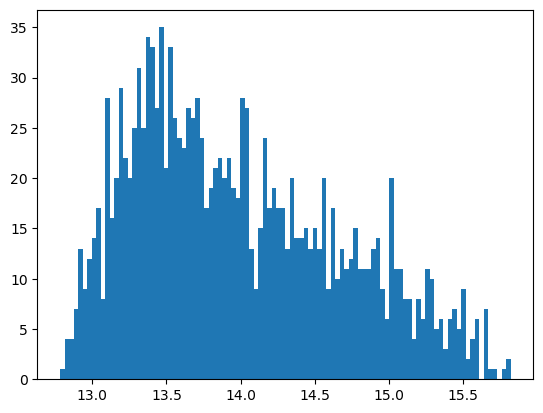

In [33]:
plt.hist(np.log10(training_data[:,80]), bins=100)
plt.show()

In [10]:
#initial try for pre-processing
#histogram of logs is less skewed than values
#try taking log10 and doing min-max after that

def log_and_norm(array):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minv = np.min(tmp)
        maxv = np.max(tmp)
        out_array[:,i] = (tmp-minv*np.ones(samples))/(maxv-minv)
        minv_arr[i] = minv
        maxv_arr[i] = maxv
        
    return(out_array, minv_arr, maxv_arr) 

In [11]:
def log_and_norm_test_set(array, minn, maxx):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minni = minn[i]
        maxxi = maxx[i]
        out_array[:,i] = (tmp-minni*np.ones(len(tmp)))/(maxxi-minni)
        
    return(out_array)

In [12]:
def post_process(array, minv_arr, maxv_arr):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    
    for i in range(len(array[0])):
        tmp = array[:,i]*(maxv[i]-minv[i])+minv[i]
        out_array[:,i] = 10**(tmp)
    
    return(out_array)

In [13]:
processed_data, minv, maxv = log_and_norm(training_data[:1300])
#plt.hist(processed_data[:,0], bins=100)
#plt.show()

In [14]:
print(training_params[1410])

[0.32614258 0.71530762 0.66830078 0.05595703 1.02478516]


In [15]:
import random

Omega_m = training_params[:1300,0]
s8 = training_params[:1300,1]
h0 = training_params[:1300,2]
Omega_b = training_params[:1300,3]
n_s = training_params[:1300,4]

smallest_om = np.min(Omega_m)
biggest_om = np.max(Omega_m)
Omega_m = (Omega_m - smallest_om)/(biggest_om - smallest_om)

smallest_s8 = np.min(s8)
biggest_s8 = np.max(s8)
s8 = (s8 - smallest_s8)/(biggest_s8 - smallest_s8)

smallest_h0 = np.min(h0)
biggest_h0 = np.max(h0)
h0 = (h0 - smallest_h0)/(biggest_h0 - smallest_h0)

smallest_ob = np.min(Omega_b)
biggest_ob = np.max(Omega_b)
Omega_b = (Omega_b - smallest_ob)/(biggest_ob - smallest_ob)

smallest_ns = np.min(n_s)
biggest_ns = np.max(n_s)
n_s = (n_s - smallest_ns)/(biggest_ns - smallest_ns)

In [15]:
import pickle

omega_m_keys = {'small': smallest_om, 'large': biggest_om}
s8_keys = {'small': smallest_s8, 'large': biggest_s8}
h0_keys = {'small': smallest_h0, 'large': biggest_h0}
omega_b_keys = {'small': smallest_ob, 'large': biggest_ob}
ns_keys = {'small': smallest_ns, 'large': biggest_ns}
params_rescale = {'Omega_m': omega_m_keys, 's8': s8_keys, 'h0': h0_keys, 'Omega_b': omega_b_keys, 'ns':ns_keys}
feature_rescale = {'small': minv, 'large': maxv}
dict_rescale_full = {'params': params_rescale, 'features': feature_rescale}
file_path = 'rescaling_for_map3_network_27Nov24.pkl'
with open(file_path, 'wb') as file:
    pickle.dump(dict_rescale_full, file)

### Load training parameters and spectra

In [16]:
modes = np.arange(144)

In [17]:
train_params = {'Omega_m': Omega_m,
          's8': s8,'h0': h0, 'Omega_b': Omega_b, 'ns': n_s,
           }

In [18]:
target_data = {'features': processed_data,
               'minimum': minv,
               'maximum': maxv
}

### Training

In [19]:
# instantiate NN class
cp_nn = cosmopower_NN(parameters=['Omega_m', 's8', 'h0', 'Omega_b', 'ns'], 
                      modes=modes, 
                      n_hidden = [64, 256, 1024, 1024, 384, 192],
                      verbose=True,
                     )


Initialized cosmopower_NN model, 
mapping 5 input parameters to 144 output modes, 
using 6 hidden layers, 
with [64, 256, 1024, 1024, 384, 192] nodes, respectively. 



In [20]:
cp_nn.restore("map3_model_27Nov24-0")

In [ ]:
#noisy_input_data = np.zeros(shape=(900,80))
#for i in range(80):
#    noisy_input_data[:,i] = processed_data[:900, i] + np.random.normal(scale=0.05, size = 900)

In [20]:
with tf.device(device):
    # train
    cp_nn.train(training_parameters=train_params,
                training_features=processed_data,
                #training_features=noisy_input_data,
                filename_saved_model='map3_model_27Nov24-0',
                # cooling schedule
                validation_split=0.25,
                learning_rates=[0.01, 0.001, 0.0001, 0.00001, 0.000001],
                #learning_rates=[0.01, 0.01, 0.01, 0.01],
                batch_sizes=[60, 30, 20, 10, 5],
                gradient_accumulation_steps = [1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [200,200,150,100, 100],
                max_epochs = [2000, 2000, 2000, 2000, 2000],
                )

Starting cosmopower_NN training, 
using 25 per cent of training samples for validation. 
Performing 5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] learning rates 
[60, 30, 20, 10, 5] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps 
[200, 200, 150, 100, 100] patience values 
[2000, 2000, 2000, 2000, 2000] max epochs 

learning rate = 0.01, batch size = 60


 46%|████████████              | 928/2000 [17:51<20:37,  1.15s/it, loss=0.00786]


Validation loss = 0.002414521
Model saved.
Reached max number of epochs. Validation loss = 0.002414521
Model saved.
learning rate = 0.001, batch size = 30


 27%|██████▋                  | 538/2000 [17:35<47:47,  1.96s/it, loss=0.000626]


Validation loss = 0.00038137977
Model saved.
Reached max number of epochs. Validation loss = 0.00038137977
Model saved.
learning rate = 0.0001, batch size = 20


...

Validation loss = 0.000111629466
Model saved.
Reached max number of epochs. Validation loss = 0.000111629466
Model saved.
learning rate = 1e-05, batch size = 10


  5%|█▏                      | 100/2000 [04:53<1:32:56,  2.94s/it, loss=8.31e-5]


Validation loss = 7.999117e-05
Model saved.
Reached max number of epochs. Validation loss = 7.999117e-05
Model saved.
learning rate = 1e-06, batch size = 5


  5%|█▏                      | 102/2000 [09:42<3:00:32,  5.71s/it, loss=6.67e-5]

Validation loss = 6.3608e-05
Model saved.
Reached max number of epochs. Validation loss = 6.3608e-05
Model saved.


In [21]:
Omega_m_test = (training_params[1300:,0]-smallest_om)/(biggest_om-smallest_om)
s8_test = (training_params[1300:,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_test = (training_params[1300:,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_test = (training_params[1300:,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_test = (training_params[1300:,4]-smallest_ns)/(biggest_ns-smallest_ns)

print(len(training_params[:,0]))
print(len(Omega_m_test))
the_test_dict = {'Omega_m': Omega_m_test,
          's8': s8_test,
                 'h0': h0_test,
                 'Omega_b': Omega_b_test,
                 'ns': ns_test,
           }
    
predictions = cp_nn.predictions_np(the_test_dict)

1471
171


In [22]:
test_set_new_scale = log_and_norm_test_set(training_data[1300:], minv, maxv)

In [23]:
predictions_rescaled = post_process(predictions, minv, maxv)

In [24]:
print(np.shape(predictions))

(171, 144)


In [25]:
print(predictions_rescaled[:,0]-training_data[1300:,0])

[-1.41521361e+05 -1.45288946e+03  5.53885216e+04 -4.14870748e+05
 -1.72943206e+04  3.44240375e+05  7.85107158e+04  3.54444756e+05
 -9.02572444e+04  2.39779127e+06 -3.83260648e+04  1.49831568e+05
 -1.11590800e+05  2.21289180e+04  4.43715573e+04  1.00788509e+05
  1.51299433e+05  5.66474882e+05  1.64923397e+05 -7.39294667e+04
  1.19589806e+05  3.01406503e+04 -2.30003088e+04 -2.16511080e+05
 -6.77571398e+04  4.81062981e+05 -1.46373151e+03 -4.49493296e+04
  4.94206234e+04 -8.52302980e+04 -1.41778608e+04 -1.89887202e+04
  2.28436676e+05  1.96013758e+05 -1.13585348e+05  2.28623485e+05
 -7.96727993e+04  4.55583449e+05 -7.82450796e+04 -5.80319055e+04
 -4.45377881e+04  4.87979673e+04  5.47997533e+03  4.58941994e+05
  7.83198628e+03 -1.79342569e+05 -1.33748380e+05 -1.68913632e+05
 -2.35702072e+05 -1.45488185e+03 -2.41627093e+04 -5.18051792e+05
 -3.54402174e+04 -4.47094686e+05 -2.55832750e+05 -8.04098657e+04
 -2.22599681e+05  2.87082874e+05 -8.36080273e+04  2.47766209e+04
  1.53788956e+05 -1.04429

In [26]:
mse = np.mean((predictions[:,0]-test_set_new_scale[:,0])**2)

In [27]:
print(mse)

4.5715265917596295e-08


In [28]:
print(predictions_rescaled[:,0])
print(training_data[1300:])

[1.33799026e+08 3.33362942e+08 3.06066644e+08 7.18265290e+08
 1.85253684e+08 2.97516423e+08 6.92752314e+07 1.15622612e+08
 7.92333732e+07 2.11019830e+09 1.48699238e+08 2.43341791e+08
 2.08940270e+08 2.03781387e+08 5.53655983e+07 2.30990340e+08
 9.38755533e+07 1.42472027e+09 2.21359332e+08 1.46630259e+08
 2.16600372e+08 1.22588336e+08 1.63337597e+08 6.38103329e+08
 1.82563075e+08 7.02898747e+08 1.19546912e+08 5.04552002e+08
 1.57337207e+08 5.65942038e+08 8.15170941e+07 1.74392946e+08
 1.05189250e+08 2.65223737e+08 1.37123253e+08 5.11716466e+08
 3.42411382e+08 7.93421860e+08 9.42608426e+07 2.21919211e+08
 1.29053688e+08 1.97674475e+08 4.67306715e+07 9.84516043e+08
 6.31980915e+07 7.80448962e+08 3.98399065e+08 2.02570813e+08
 9.78789863e+07 2.50697829e+08 1.06150060e+08 1.14140186e+09
 1.04422183e+08 1.30436946e+09 2.17178805e+08 2.72050809e+08
 4.03566520e+08 7.83573894e+08 5.89785349e+07 2.36657112e+08
 1.65168034e+08 3.07738998e+08 2.15923223e+08 1.76559808e+08
 4.71326727e+07 4.373399

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(training_data[1300:,0],predictions_rescaled[:,0], s=0.5, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [29]:
test_data_all = training_data[1300:].flatten()
pred_rescaled_all = predictions_rescaled.flatten()

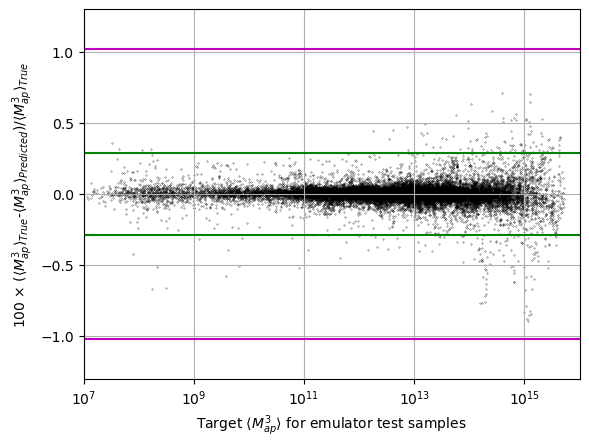

In [30]:
#plt.title("Performance of Map3 emulator")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_data_all,100*(pred_rescaled_all-test_data_all)/test_data_all, s=0.05, color='k')
plt.ylim(-1.3,1.3)
plt.hlines(1.02, xmin=10**(7),xmax=10**(16), color='m')
plt.hlines(-1.02, xmin=10**(7),xmax=10**(16), color='m')
plt.hlines(0.29, xmin=10**(7),xmax=10**(16), color='g')
plt.hlines(-0.29, xmin=10**(7),xmax=10**(16), color='g')
plt.xlim(10**7, 10**16)
plt.ylabel(r"100 $\times$ ($\langle M_{ap}^3 \rangle_{True}$-$\langle M_{ap}^3 \rangle_{Predicted}$)/$\langle M_{ap}^3 \rangle_{True}$")
plt.xscale('log')
plt.xlabel(r"Target $\langle M_{ap}^3 \rangle$ for emulator test samples")
plt.grid()
#plt.show()
plt.savefig('Percentual_difference_27Nov24.png', dpi=600)

In [41]:
count1 = 0
count2 = 0
for i in range(len(test_data_all)):
    x = 100*(pred_rescaled_all[i]-test_data_all[i])/test_data_all[i]
    if np.abs(x) < 0.29:
        count1+=1
    if np.abs(x) < 1.02:
        count2+=1
print(count1/len(test_data_all))
print(count2/len(test_data_all))

0.9902940220922677
1.0


In [ ]:
#compare performance of integrated results (at cosmoDESY3)
from astropy.io import fits
fastnc = fits.open("../../data/dv/sim_map3_emu-NLA-cosmoDESY3-02Nov24-8arcmincut-emuconfigs-no-emu.fits")
emu = fits.open("../../data/dv/sim_map3_emu-NLA-cosmoDESY3-02Nov24-8arcmincut-emulator.fits")

target = np.zeros(80)
pred = np.zeros(80)
for i in range(80):
    target[i] = fastnc[1].data[i][6]
    pred[i] = emu[1].data[i][6]
    
percent_diff = 100*(target-pred)/target
print(percent_diff)

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,0], predictions[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
all_true = test_set_new_scale.flatten()
all_pred = predictions.flatten()

In [ ]:
plt.title("map3 emulator performance, all elements of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred, s=0.5)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("emulator performance before los integration, all cosmo params")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred-all_true, s=0.05, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted-True")
#plt.show()
plt.savefig('all_cosmo_params_emulator_performance.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,42], predictions[:,42]-test_set_new_scale[:,42], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(np.log10(training_data[1300:,35]), np.log10(predictions_rescaled[:,35]), s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
plt.scatter(training_data[900:,1],-training_data[900:,1]+predictions_rescaled[:,1], s=2)
#plt.scatter(training_data[900:,0], predictions_rescaled[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()
#plt.savefig("Map3_emulator_scatter_diff.png")

In [ ]:
#test with single param. COSMO1 = n200. COSMO 2 = [0.46270508 0.75046387 0.69642578 0.03283203 0.98416016] (n1440)
Omega_m_sp = (training_params[1440:1441,0]-smallest_om)/(biggest_om-smallest_om)
s8_sp = (training_params[1440:1441,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_sp = (training_params[1440:1441,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_sp = (training_params[1440:1441,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_sp = (training_params[1440:1441,4]-smallest_ns)/(biggest_ns-smallest_ns)

#print(len(training_params[:,0]))
#print(len(Omega_m_test))
the_test_dict_sp = {'Omega_m': Omega_m_sp,
          's8': s8_sp,
                 'h0': h0_sp,
                 'Omega_b': Omega_b_sp,
                 'ns': ns_sp,
           }
    
predictions_sp = cp_nn.predictions_np(the_test_dict_sp)

In [ ]:
predictions_rescaled_sp = post_process(predictions_sp, minv, maxv)

In [ ]:
print(np.shape(training_data[1440]))

In [ ]:
save_true = np.zeros(shape=(1,144))
save_pred = np.zeros(shape=(1,144))
save_true[0] = training_data[1440]
save_pred[0] = predictions_rescaled_sp
#print((training_data[1440]-predictions_rescaled_sp)/training_data[1440])
np.save("true_value_cosmo2", save_true)
np.save("pred_value_cosmo2", save_pred)

In [ ]:
print(np.shape(predictions_rescaled_sp))

In [ ]:
print(np.shape(predictions_rescaled_sp[0,0::4]))

In [ ]:
filter_1_info = training_data[1440][0::4]
filter_2_info = training_data[1440][1::4]
filter_3_info = training_data[1440][2::4]
filter_4_info = training_data[1440][3::4]
zarray1 = np.array([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07])
zarray2 = np.linspace(0.1, 1.5, num = 29)
zarray = np.concatenate((zarray1, zarray2))

In [ ]:
import matplotlib.pyplot as plt

plt.title("Map3 signal per redshift")
plt.xlabel("z")
plt.ylabel("Equal aperture Map3")
plt.plot(zarray, filter_1_info, label='7 arcmin')
plt.plot(zarray, filter_2_info, label='14 arcmin')
plt.plot(zarray, filter_3_info, label='25 arcmin')
plt.plot(zarray, filter_4_info, label='40 arcmin')
plt.grid()
plt.legend()
plt.show()

In [ ]:
test_data_lowz_7arcmin = training_data[1300:][0:32:4].flatten()
pred_rescaled_lowz_7arcmin = predictions_rescaled[0:32:4].flatten()

In [ ]:
test_data_lowz_14arcmin = training_data[1300:][1:32:4].flatten()
pred_rescaled_lowz_14arcmin = predictions_rescaled[1:32:4].flatten()

In [ ]:
test_data_lowz_25arcmin = training_data[1300:][2:32:4].flatten()
pred_rescaled_lowz_25arcmin = predictions_rescaled[2:32:4].flatten()

In [ ]:
test_data_lowz_40arcmin = training_data[1300:][3:32:4].flatten()
pred_rescaled_lowz_40arcmin = predictions_rescaled[3:32:4].flatten()

In [ ]:
plt.title("Performance of Map3 emulator, 0<z<0.1")
plt.scatter(test_data_lowz_7arcmin,100*(pred_rescaled_lowz_7arcmin-test_data_lowz_7arcmin)/test_data_lowz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_lowz_14arcmin,100*(pred_rescaled_lowz_14arcmin-test_data_lowz_14arcmin)/test_data_lowz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_lowz_25arcmin,100*(pred_rescaled_lowz_25arcmin-test_data_lowz_25arcmin)/test_data_lowz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_lowz_40arcmin,100*(pred_rescaled_lowz_40arcmin-test_data_lowz_40arcmin)/test_data_lowz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_data_midz_7arcmin = training_data[1300:][32:80:4].flatten()
pred_rescaled_midz_7arcmin = predictions_rescaled[32:80:4].flatten()
test_data_midz_14arcmin = training_data[1300:][33:80:4].flatten()
pred_rescaled_midz_14arcmin = predictions_rescaled[33:80:4].flatten()
test_data_midz_25arcmin = training_data[1300:][34:80:4].flatten()
pred_rescaled_midz_25arcmin = predictions_rescaled[34:80:4].flatten()
test_data_midz_40arcmin = training_data[1300:][35:80:4].flatten()
pred_rescaled_midz_40arcmin = predictions_rescaled[35:80:4].flatten()

In [ ]:
plt.title("Performance of Map3 emulator, 0.1<z<0.7")
plt.scatter(test_data_midz_7arcmin,100*(pred_rescaled_midz_7arcmin-test_data_midz_7arcmin)/test_data_midz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_midz_14arcmin,100*(pred_rescaled_midz_14arcmin-test_data_midz_14arcmin)/test_data_midz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_midz_25arcmin,100*(pred_rescaled_midz_25arcmin-test_data_midz_25arcmin)/test_data_midz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_midz_40arcmin,100*(pred_rescaled_midz_40arcmin-test_data_midz_40arcmin)/test_data_midz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [ ]:
path_to_train = '../../'
cosmo2_morez = np.loadtxt(path_to_train + "output/true-map3-vals-cosmo2.txt")[25:-2]
print(np.shape(cosmo2_morez))

In [ ]:
save_true_finez = np.zeros(shape=(1,256))
save_true_finez[0] = cosmo2_morez
np.save("true_value_cosmo2_fine_z", save_true_finez)